In [108]:
#Exercicio 1:

import numpy as np
import matplotlib.pyplot as plt

#1.1 Binomial negativa via Bernoullis

p = 0.5
r = 5
K = 1000

def binomial_negativa_bernoulli(p,r):
    tentativas = 0
    acerto = 0
    
    while acerto < r:
        tentativas += 1
        bernoulli = np.random.uniform()

        if bernoulli < p:
            acerto += 1

    return tentativas

print(binomial_negativa_bernoulli(p,r))


13


In [109]:
#1.1 Binomial negativa via soma de geométricas

def binomial_negativa_geometrica(p,r):
    soma = 0

    for i in range(r):
        tentativas_geo = 0
        sucesso = False

        while sucesso == False:
            tentativas_geo += 1
            u = np.random.uniform()

            if u < p:
                sucesso = True

        soma += tentativas_geo

    return soma

print(binomial_negativa_geometrica(p,r))

12


In [110]:
#1.1 Binomial negativa via recursão

def binomial_negativa_recursiva(p,r):
    U = np.random.uniform(0,1)
    n = r
    p_n = p**r
    F = p_n

    while U > F:
        p_n = p_n * ((n)/(n-r+1)) * (1-p)
        n = n + 1
        F = F + p_n

    return n 

print(binomial_negativa_recursiva(p,r))

12


In [111]:
#1.2 Gerando amostra pelo numpy

def binomial_negativa_amostra(p,r,K, metodo):
    amostra = []
    for j in range(K):
        if metodo == "bernoulli":
            resultado = binomial_negativa_bernoulli(p,r)
        elif metodo == "geometrica":
            resultado = binomial_negativa_geometrica(p,r)
        elif metodo == "recursiva":
            resultado = binomial_negativa_recursiva(p,r)

        amostra.append(resultado)

    return amostra

amostra_bernoulli = binomial_negativa_amostra(p,r,K, "bernoulli")
amostra_geometrica = binomial_negativa_amostra(p,r,K, "geometrica")
amostra_recursiva = binomial_negativa_amostra(p,r,K, "recursiva")
amostra_numpy = np.random.negative_binomial(r,p,K) + r


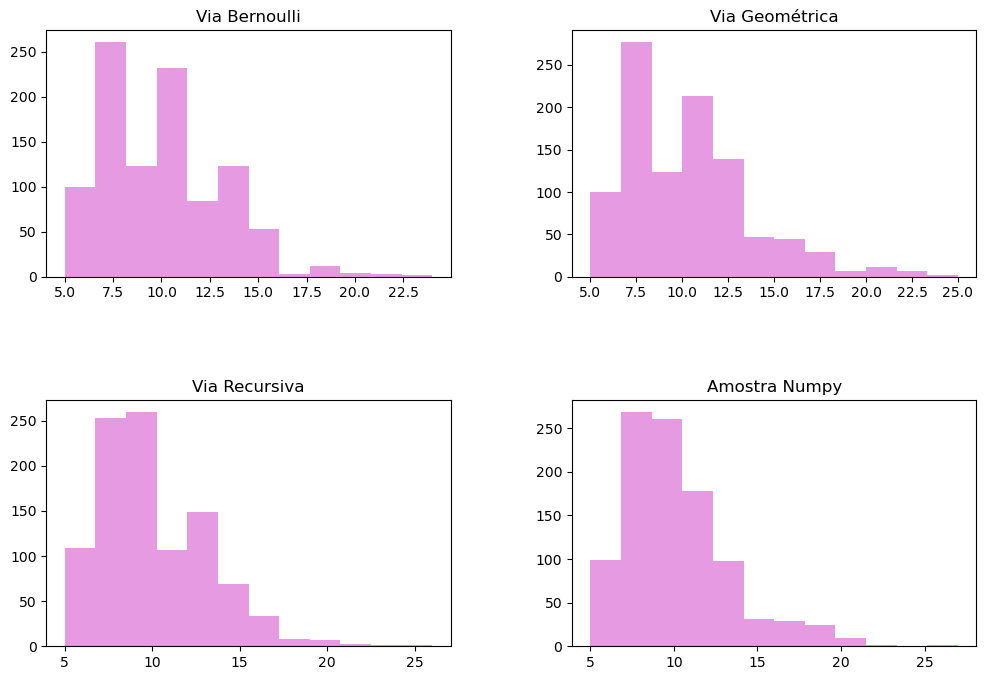

In [112]:
# 1.2 Gerando histogramas

fig, eixo = plt.subplots(2,2, figsize=(12, 8)) 
plt.subplots_adjust(hspace=0.5, wspace=0.3)

eixo[0,0].hist(amostra_bernoulli, bins= 12, color='orchid', alpha=0.7)
eixo[0,0].set_title("Via Bernoulli")

eixo[0,1].hist(amostra_geometrica, bins= 12, color='orchid', alpha=0.7)
eixo[0,1].set_title("Via Geométrica")

eixo[1,0].hist(amostra_recursiva, bins= 12, color='orchid', alpha=0.7)
eixo[1,0].set_title("Via Recursiva")

eixo[1,1].hist(amostra_numpy, bins= 12, color='orchid', alpha=0.7)
eixo[1,1].set_title("Amostra Numpy")

plt.show()

In [113]:
#1.3 Comparando os tempos

import time

inicio = time.time()
binomial_negativa_amostra(p,r,K, "bernoulli")
tempo_bernoulli = time.time() - inicio
print(f"Tempo Bernoulli: {tempo_bernoulli: .4f} segundos")

inicio = time.time()
binomial_negativa_amostra(p,r,K, "geometrica")
tempo_geometrica = time.time() - inicio
print(f"Tempo Geometrica: {tempo_geometrica: .4f} segundos")


inicio = time.time()
binomial_negativa_amostra(p,r,K, "recursiva")
tempo_recursiva = time.time() - inicio
print(f"Tempo Recursiva: {tempo_recursiva: .4f} segundos")

inicio = time.time()
np.random.negative_binomial(r,p,K)
tempo_numpy = time.time() - inicio
print(f"Tempo Numpy: {tempo_numpy: .4f} segundos")




Tempo Bernoulli:  0.0290 segundos
Tempo Geometrica:  0.0330 segundos
Tempo Recursiva:  0.0060 segundos
Tempo Numpy:  0.0010 segundos


In [114]:
#Exercicio 2

#2.1 Gerando uma função pra aplicar o método de embaralhamento de FiSher-Yates

M = 55
N = 20
n = 10
K = 1000

def embaralhamento_fisher_yates(urna, versao):

    M = len(urna)

    for i in range(M-1):
        if versao == "correta":
            j = np.random.randint(i,M)

        elif versao == "errada":
            j = np.random.randint(0,M)

        temp = urna[i]
        urna[i] = urna[j]
        urna[j] = temp

    return urna
    

In [115]:
#2.1 Gerando uma amostra HG

def hipergeometrica_fisher_yates(M,N,n, versao):
    urna = []
    for i in range(N):
        urna.append(1)
    for i in range(M - N):
        urna.append(0)

    urna_embaralhada = embaralhamento_fisher_yates(urna, versao)

    sucessos = 0
    for k in range(n):
        if urna_embaralhada[k] == 1:
            sucessos += 1

    return sucessos

In [116]:
#2.2 Gerando amostra HG com numpy

def amostra_hipergeometrica(M,N,n,K, versao):
    amostra = []
    for i in range(K):
        resultado = hipergeometrica_fisher_yates(M,N,n, versao)
        amostra.append(resultado)
    return amostra

amostra_correta = amostra_hipergeometrica(M,N,n,K, "correta")
amostra_errada = amostra_hipergeometrica(M,N,n,K, "errada")
amostra_numpy = np.random.hypergeometric(N, M - N, n, size = K)


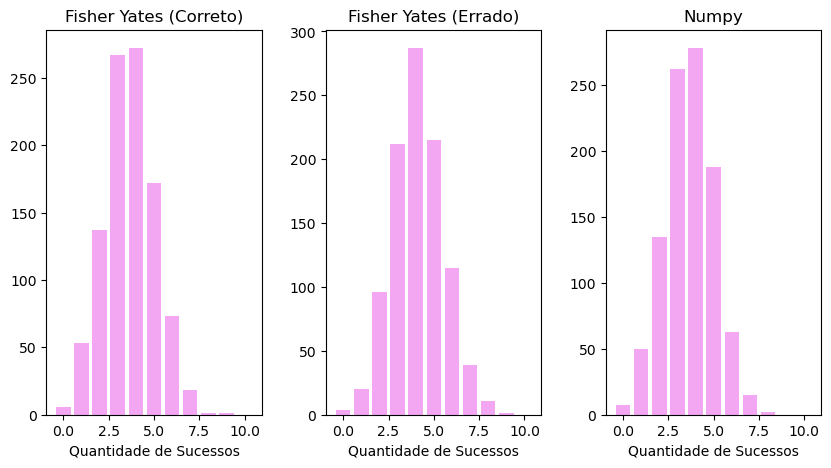

In [117]:
#2.2 Gerando histogramas 

fig, eixo = plt.subplots(1,3, figsize=(10, 5))
plt.subplots_adjust(wspace=0.3)


eixo[0].hist(amostra_correta, bins=range(n+2), color = 'violet', alpha=0.7, align='left', rwidth=0.8)
eixo[0].set_title("Fisher Yates (Correto)")
eixo[0].set_xlabel("Quantidade de Sucessos")

eixo[1].hist(amostra_errada, bins=range(n+2), color = 'violet', alpha=0.7, align='left', rwidth=0.8)
eixo[1].set_title("Fisher Yates (Errado)")
eixo[1].set_xlabel("Quantidade de Sucessos")

eixo[2].hist(amostra_numpy, bins=range(n+2), color = 'violet', alpha=0.7, align='left', rwidth=0.8)
eixo[2].set_title("Numpy")
eixo[2].set_xlabel("Quantidade de Sucessos")

plt.show()

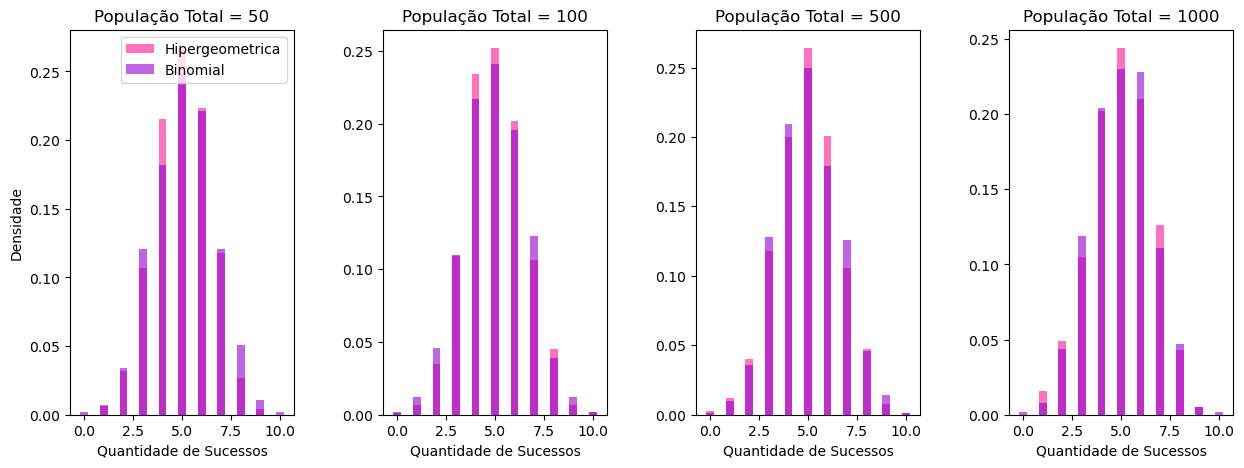

In [126]:
#Exercicio 3

n=10
K=1000
p=0.5

def amostra_hipergeometrica(M,N,n,K):
    amostra = []
    for i in range(K):
        urna = []
        for j in range(N):
            urna.append(1)
        for j in range(M):
            urna.append(0)

        tamanho = len(urna)
        for k in range(tamanho - 1):
            j = np.random.randint(k, tamanho)
            temp = urna[k]
            urna[k] = urna[j]
            urna[j] = temp

        sucessos = 0
        for k in range(n):
            if urna[k] == 1:
                sucessos += 1
        amostra.append(sucessos)

    return amostra

def amostra_binomial(n,p,K):
    return list(np.random.binomial(n,p,size=K))


populacao = [50, 100, 500, 1000]

fig, eixo = plt.subplots(1,4, figsize=(15,5))
plt.subplots_adjust(wspace=0.4)

for i in range(len(populacao)):
    total = populacao[i]

    N = int(total * p)
    M = total - N

    amostra_HG = amostra_hipergeometrica(M,N,n,K)
    amostra_bin = amostra_binomial(n,p,K)

    histograma = eixo[i]
    histograma.hist(amostra_HG, bins=range(n+2), density=True, alpha=0.6, color='deeppink',
                    align='left', rwidth=0.4, label='Hipergeometrica')
    histograma.hist(amostra_bin, bins=range(n+2), density=True, alpha=0.6, color='darkviolet',
                    align='left', rwidth=0.4, label='Binomial')
    histograma.set_title(f"População Total = {total}")
    histograma.set_xlabel("Quantidade de Sucessos")
    if i == 0:
        histograma.set_ylabel("Densidade")
        histograma.legend()

plt.show()

